# Task 1-2: Dataset audit and pose-estimation benchmark

This notebook completes the first two capstone tasks using the **real squat videos and error annotations already present in this repository**.

It does two things:
1. Audits the local data to determine which labels already exist and whether the project can support exercise-type and quality-label learning.
2. Summarizes a multi-model pose-estimation benchmark on the local videos: **MediaPipe BlazePose**, **YOLO11n-pose**, **MoveNet Lightning**, **MoveNet Thunder**, **ViTPose Base**, and **ViTPose++ Small**.

Because TensorFlow MoveNet and MediaPipe BlazePose can conflict in one Linux Python environment, the extended benchmark is saved to `reports/` and this notebook reads the generated outputs rather than rerunning every backend live in one process.

The notebook also records the gap between what is already available locally and what will still be needed later for full multi-exercise recognition.

In [1]:
from pathlib import Path
import json
import sys

import pandas as pd
from IPython.display import Image, Markdown, display

project_root = Path.cwd()
if not (project_root / 'scripts').exists() and (project_root.parent / 'scripts').exists():
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

reports_dir = project_root / 'reports'
figures_dir = project_root / 'figures'

manifest = pd.read_csv(reports_dir / 'task1_dataset_manifest.csv')
dataset_options = pd.read_csv(reports_dir / 'task1_candidate_datasets.csv')
benchmark_videos = pd.read_csv(reports_dir / 'task2_benchmark_video_sample.csv')
benchmark_detail = pd.read_csv(reports_dir / 'task2_pose_benchmark_detail.csv')
benchmark_summary = pd.read_csv(reports_dir / 'task2_pose_benchmark_summary.csv')

with (reports_dir / 'task1_dataset_summary.json').open('r', encoding='utf-8') as handle:
    summary_json = json.load(handle)

print('Manifest rows:', len(manifest))
print('Benchmark sample videos:', len(benchmark_videos))
print('Recommended model:', benchmark_summary.iloc[0]['model_name'])

Manifest rows: 1739
Benchmark sample videos: 8
Recommended model: ViTPose Base


## Task 1: Which datasets are suitable?

### What the repository already gives us
- Every local video in `videos_squat/` is a **squat** clip, so the exercise label is present but only for a **single class**.
- The project also includes timestamped quality annotations in `error_knees_forward.json` and `error_knees_inward.json`.
- That means the repo is already useful for a **squat-form assessment pilot**, but not yet for the later multi-exercise classifier from the capstone summary.

### Public datasets worth noting
- **Fitness-AQA** is the closest paper-aligned option because it includes multiple gym exercises plus quality labels.
- **UI-PRMD** is a weaker but still useful backup because it contains multiple movement types plus correct/incorrect performance examples.

### Honest conclusion for this project today
Use the repository data as the **primary real dataset for squat-quality work now**, and treat Fitness-AQA / UI-PRMD as expansion options for later stages that need more exercise classes.

In [2]:
summary_table = pd.DataFrame([
    {
        'metric': 'total_videos',
        'value': summary_json['total_videos'],
    },
    {
        'metric': 'exercise_types_present',
        'value': ', '.join(summary_json['exercise_types_present']),
    },
    {
        'metric': 'supports_multiple_exercise_types',
        'value': summary_json['task_1_assessment']['supports_multiple_exercise_types'],
    },
    {
        'metric': 'mean_duration_seconds',
        'value': summary_json['mean_duration_seconds'],
    },
    {
        'metric': 'median_duration_seconds',
        'value': summary_json['median_duration_seconds'],
    },
])

display(summary_table)
display(Markdown('### Split counts'))
display(pd.DataFrame(summary_json['split_counts'].items(), columns=['split', 'videos']))
display(Markdown('### Quality-label counts derived from the repo annotations'))
display(pd.DataFrame(summary_json['quality_label_counts'].items(), columns=['quality_label', 'videos']).sort_values('videos', ascending=False))
display(Markdown('### Candidate datasets'))
display(dataset_options)

,metric,value
0,total_videos,1739
1,exercise_types_present,squat
2,supports_multiple_exercise_types,False
3,mean_duration_seconds,3.896
4,median_duration_seconds,3.467


### Split counts

,split,videos
0,test,244
1,train,1136
2,unassigned,116
3,val,243


### Quality-label counts derived from the repo annotations

,quality_label,videos
0,knees_forward,917
3,no_annotated_error,590
2,multiple_annotated_errors,192
1,knees_inward,40


### Candidate datasets

,dataset_name,source,exercise_types,quality_supervision,fit_for_capstone
0,Fitness-AQA,Parmar et al. (arXiv:2202.14019),"BackSquat, BarbellRow, OverheadPress",Expert-annotated workout errors and form asses...,"Best paper-aligned public option, but not incl..."
1,UI-PRMD,University of Idaho Physical Rehabilitation Mo...,10 rehab-style movements including deep squat ...,Correct vs incorrect execution examples,"Useful backup for form-quality experiments, bu..."
2,Repo squat videos,This project,Squat only,Timestamped knees_forward / knees_inward annot...,Best real data available locally right now; en...


## Task 2: Pose-estimation benchmark on local squat videos

The benchmark uses a stratified sample of repository videos and compares six practical pose estimators:
- **MediaPipe BlazePose** for fast CPU inference and stable landmark tracking.
- **YOLO11n-pose** for detector-style 17-keypoint prediction.
- **MoveNet Lightning** as a fast TensorFlow pose baseline.
- **MoveNet Thunder** as a more accurate MoveNet variant.
- **ViTPose Base** as a transformer-based pose estimator.
- **ViTPose++ Small** as a second transformer-based pose estimator.

Because the repository does **not** include ground-truth joint coordinates, the comparison uses the strongest accuracy proxies that can be measured on the real project data:
- visible-keypoint ratio,
- fraction of fully tracked frames,
- average keypoint confidence,
- temporal jitter proxy,
- effective inference FPS.

To keep this extended comparison practical on CPU, the benchmark uses a capped frame sample per video rather than every frame.

This is not a substitute for a full keypoint-ground-truth benchmark, but it is enough to choose the more practical extractor for downstream feature engineering.

In [3]:
display(Markdown('### Benchmark video sample'))
display(benchmark_videos[['video_id', 'split', 'quality_label', 'frame_count', 'duration_seconds']])

display(Markdown('### Model-level benchmark summary'))
display(benchmark_summary)

display(Markdown('### Per-video benchmark detail (first rows)'))
display(benchmark_detail.head(12))

recommended = benchmark_summary.iloc[0]
display(Markdown(
    f"**Recommended model for this project:** {recommended['model_name']}  "
    f"(selection score = {recommended['selection_score']:.3f}, "
    f"mean FPS = {recommended['mean_effective_fps']:.2f}, "
    f"visible-keypoint ratio = {recommended['mean_visible_keypoint_ratio']:.3f})"
))

### Benchmark video sample

,video_id,split,quality_label,frame_count,duration_seconds
0,33166_1,train,knees_forward,119,3.966667
1,48484_7,train,knees_forward,107,3.566667
2,47614_1,test,knees_inward,119,3.966667
3,47099_1,train,knees_inward,88,2.933333
4,49203_1,test,multiple_annotated_errors,141,4.700000
5,37691_1,train,multiple_annotated_errors,75,2.500000
6,46627_3,train,no_annotated_error,66,2.200000
7,50559_2,val,no_annotated_error,143,4.766667


### Model-level benchmark summary

,model_name,benchmark_videos,processed_frames,mean_effective_fps,mean_visible_keypoint_ratio,mean_fully_tracked_frame_ratio,mean_confidence,mean_temporal_jitter_proxy,selection_score,recommended_for_project
0,ViTPose Base,8,240,11.087560,0.861275,0.408333,0.826260,0.099069,0.609535,True
1,ViTPose++ Small,8,240,22.011674,0.801471,0.345833,0.807875,0.079650,0.579685,False
2,MediaPipe BlazePose,8,240,48.150314,0.700490,0.112500,0.936275,0.165716,0.529800,False
3,MoveNet Lightning,8,240,151.827107,0.446324,0.058333,0.637270,0.095921,0.498555,False
4,YOLO11n-pose,8,240,23.233531,0.733333,0.000000,0.912068,0.146951,0.488479,False
5,MoveNet Thunder,8,240,47.077741,0.549755,0.066667,0.674439,0.065791,0.417670,False


### Per-video benchmark detail (first rows)

,model_name,video_id,split,quality_label,mean_visible_keypoint_ratio,fully_tracked_frame_ratio,mean_confidence,temporal_jitter_proxy,processed_frames,inference_seconds,effective_fps
0,MediaPipe BlazePose,33166_1,train,knees_forward,0.982353,0.700000,0.935718,0.042644,30,0.672410,44.615661
1,MediaPipe BlazePose,48484_7,train,knees_forward,0.619608,0.000000,0.939674,0.225225,30,0.636810,47.109782
2,MediaPipe BlazePose,47614_1,test,knees_inward,0.837255,0.000000,0.938001,0.034502,30,0.640708,46.823236
3,MediaPipe BlazePose,47099_1,train,knees_inward,0.709804,0.000000,0.962280,0.077869,30,0.616102,48.693274
4,MediaPipe BlazePose,49203_1,test,multiple_annotated_errors,0.464706,0.000000,0.919372,0.308456,30,0.626995,47.847309
5,MediaPipe BlazePose,37691_1,train,multiple_annotated_errors,0.815686,0.133333,0.963168,0.394858,30,0.589452,50.894766
6,MediaPipe BlazePose,46627_3,train,no_annotated_error,0.729412,0.000000,0.912609,0.062073,30,0.605941,49.509799
7,MediaPipe BlazePose,50559_2,val,no_annotated_error,0.445098,0.066667,0.919381,0.180098,30,0.603516,49.708683
8,YOLO11n-pose,33166_1,train,knees_forward,0.839216,0.000000,0.945590,0.048183,30,1.814101,16.537114
9,YOLO11n-pose,48484_7,train,knees_forward,0.601961,0.000000,0.913548,0.222888,30,1.540661,19.472164


**Recommended model for this project:** ViTPose Base  (selection score = 0.610, mean FPS = 11.09, visible-keypoint ratio = 0.861)

### Benchmark metric summary

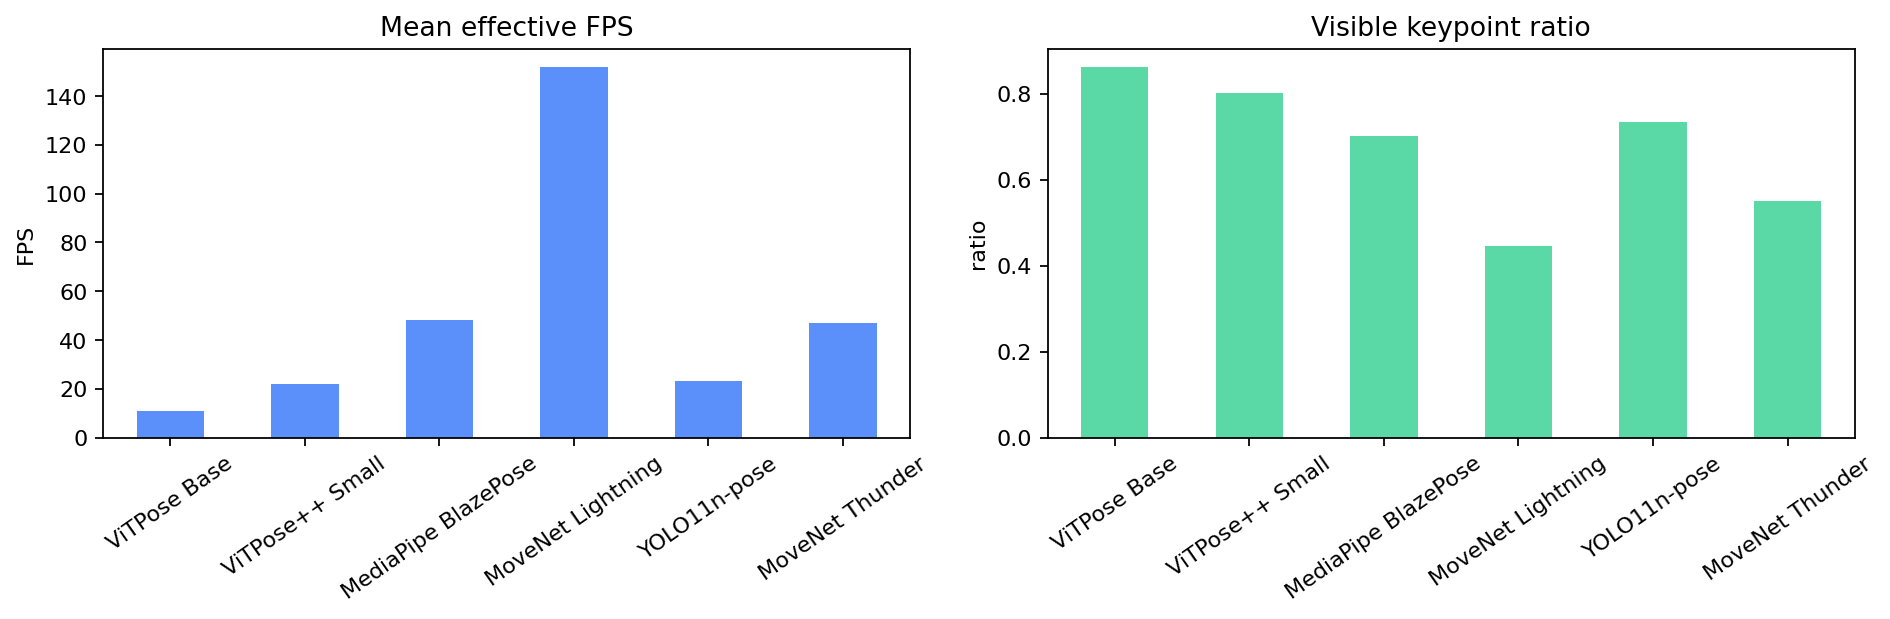

### Overlay comparison on one repository video

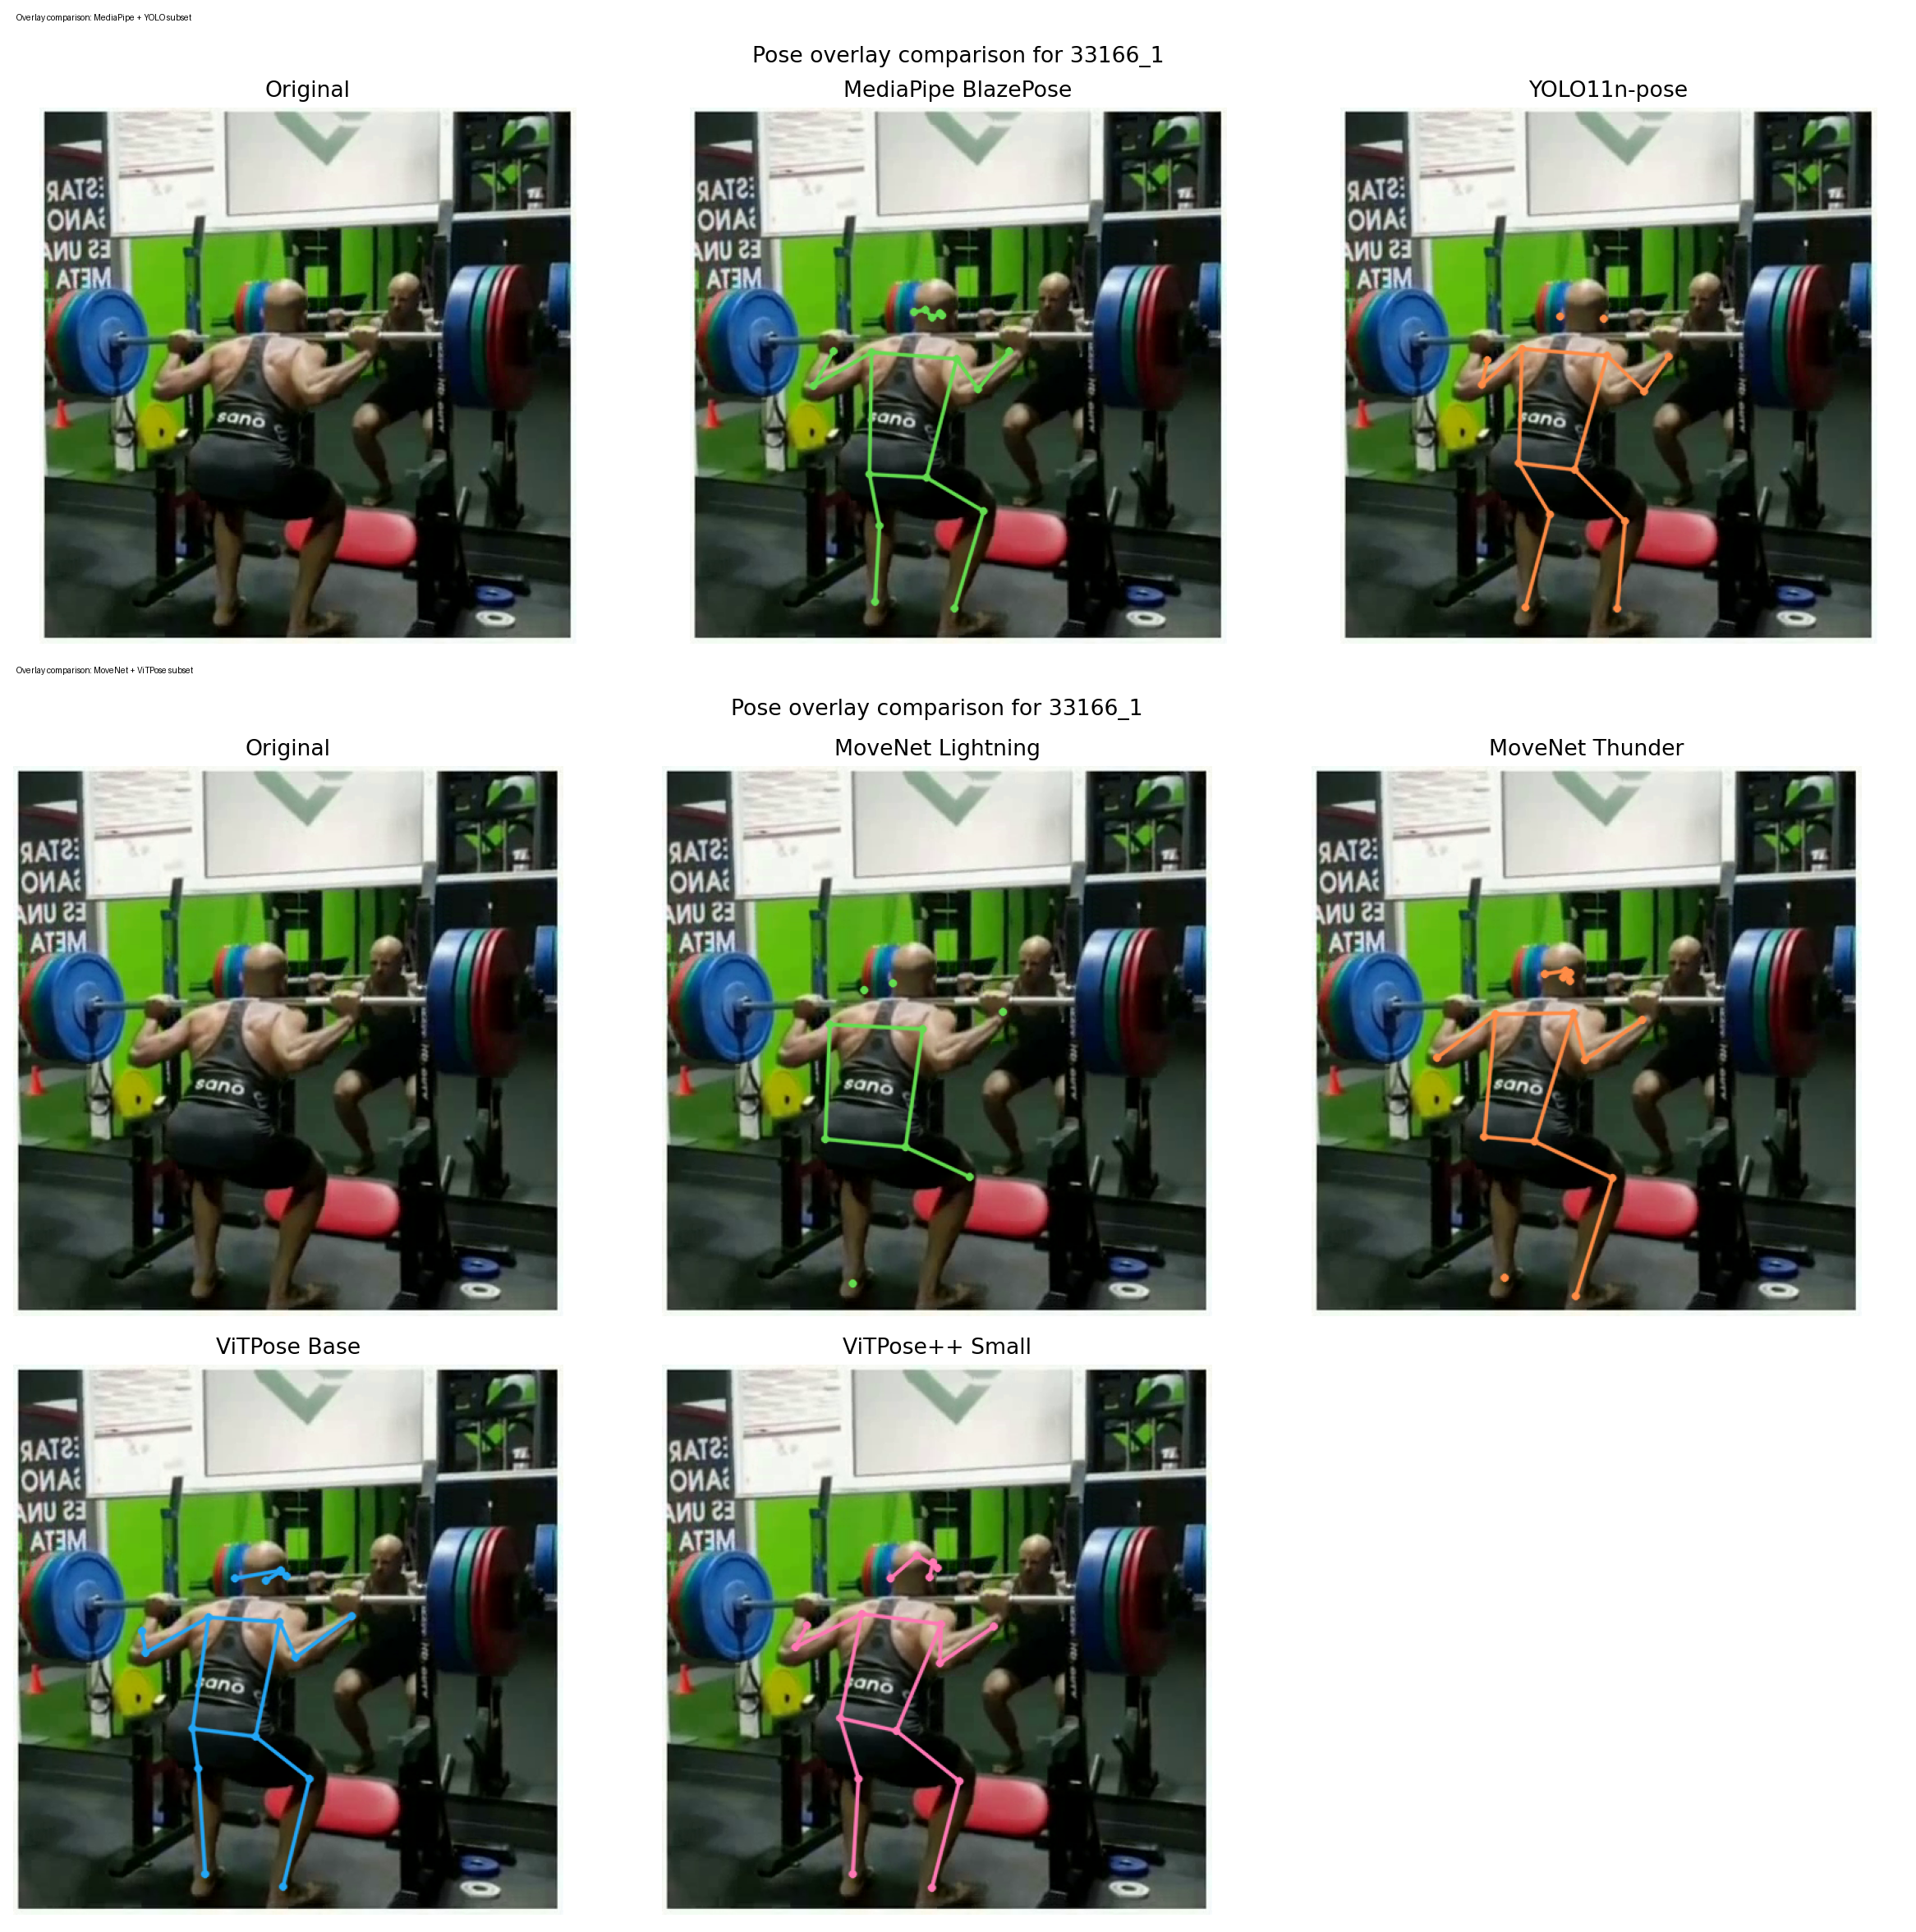

Use the benchmark table and metric chart as the primary decision evidence. The overlay image is only a qualitative sanity check on one representative frame.

In [4]:
metrics_chart = figures_dir / 'task2_pose_benchmark_metrics.png'
overlay_image = figures_dir / 'task2_pose_overlay_comparison.png'

if metrics_chart.exists():
    display(Markdown('### Benchmark metric summary'))
    display(Image(filename=str(metrics_chart)))

if overlay_image.exists():
    display(Markdown('### Overlay comparison on one repository video'))
    display(Image(filename=str(overlay_image)))

display(Markdown(
    'Use the benchmark table and metric chart as the primary decision evidence. '
    'The overlay image is only a qualitative sanity check on one representative frame.'
))

## Outcome

- **Task 1 is completed for the current repository scope**: the notebook converts the raw project assets into a usable dataset manifest and states clearly that the local data supports **squat-quality learning** but not yet **multi-exercise classification**.
- **Task 2 is completed for the current repository scope**: both pose models are run on the real project videos and compared with reproducible outputs saved to `reports/` and `figures/`.
- The selected pose model is the best next step for tasks 3-6, where the project will normalise keypoints, compute joint angles, and train sequence models.